# Exploratory Analysis of Polish Housing Market
- Data:  Rejestr Cen Nieruchomości
- Autor: Dawid Boratynski

---
Useful links:
- https://www.youtube.com/watch?v=byyPDYkCsiU
- https://www.geoportal.gov.pl/pl/dane/rejestr-cen-nieruchomosci-rcn/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [2]:
df = pd.read_parquet('data.parquet')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8213228 entries, 0 to 8213227
Data columns (total 28 columns):
 #   Column                Dtype         
---  ------                -----         
 0   gid                   int32         
 1   serwis_rcn            object        
 2   teryt                 object        
 3   tran_przestrzen_nazw  object        
 4   tran_lokalny_id_iip   object        
 5   tran_wersja_id        object        
 6   tran_rodzaj_trans     object        
 7   tran_rodzaj_rynku     object        
 8   tran_sprzedajacy      object        
 9   tran_kupujacy         object        
 10  tran_cena_brutto      float64       
 11  tran_vat              float64       
 12  dok_data              datetime64[ms]
 13  nier_rodzaj           object        
 14  nier_prawo            object        
 15  nier_udzial           object        
 16  nier_pow_gruntu       float64       
 17  nier_cena_brutto      float64       
 18  nier_vat              float64       
 19  

In [8]:
df.describe()

,gid,tran_cena_brutto,tran_vat,dok_data,nier_pow_gruntu,nier_cena_brutto,nier_vat,bud_pow_uzyt,bud_cena_brutto,bud_vat
count,8.213228e+06,8.174304e+06,7.159780e+05,8141426,2.964244e+06,5.264315e+06,4.271030e+05,1.779511e+06,1.312190e+05,3.711000e+03
mean,2.130525e+07,1.022823e+06,1.711408e+05,2019-08-14 13:53:03.301000,1.800646e+04,3.810984e+08,2.154399e+05,2.797159e+03,3.171076e+05,1.071211e+05
min,2.103300e+05,0.000000e+00,-1.230569e+08,0014-05-09 01:24:00.001000,0.000000e+00,0.000000e+00,-5.865880e+08,-1.000000e+00,0.000000e+00,-1.303363e+08
25%,1.716804e+07,1.200000e+05,8.000000e+00,2017-01-19 00:00:00,3.000000e-01,5.500000e+04,0.000000e+00,1.477200e+02,0.000000e+00,0.000000e+00
50%,2.086214e+07,2.600000e+05,2.300000e+01,2020-11-05 00:00:00,2.000000e+01,2.340662e+05,1.629600e+04,1.124400e+03,0.000000e+00,8.000000e+00
75%,2.714875e+07,4.351000e+05,2.716169e+04,2023-07-03 00:00:00,6.720000e+02,4.100000e+05,3.333333e+04,3.171900e+03,6.000000e+04,1.324294e+04
max,2.931962e+07,7.636707e+11,1.725000e+09,9202-01-30 00:00:00,6.557200e+08,1.000430e+15,1.725000e+09,2.583800e+07,2.298780e+09,8.262017e+07
std,6.434690e+06,3.435904e+08,5.649724e+06,NaN,2.377102e+06,6.166385e+11,7.065364e+06,5.574810e+04,9.820095e+06,3.331823e+06


In [9]:
df.head()

,gid,serwis_rcn,teryt,tran_przestrzen_nazw,tran_lokalny_id_iip,tran_wersja_id,tran_rodzaj_trans,tran_rodzaj_rynku,tran_sprzedajacy,tran_kupujacy,...,nier_vat,bud_id_budynku,bud_nr_budynku,bud_rodzaj,bud_pow_uzyt,bud_cena_brutto,bud_vat,bud_adres,geometry,geometry_bbox
0,5549286,NaN,1604,PL.PZGiK.4784.RCN,705B7A19-CA7B-4341-A63E-770B6D6A91CE,2023-08-28T11:47:03,wolnyRynek,wtorny,osobaFizyczna,osobaFizyczna,...,NaN,160402_4.0027.2733_BUD,2733_BUD,NaN,NaN,NaN,NaN,MSC:KLUCZBORK;UL:KATOWICKA;NR_PORZ:24,None,None
1,5600853,NaN,1807,PL.PZGiK.3860.RCiWN,3ff00102-ac6a-46b1-9fae-96439e1306ea,2012-10-12T19:18:51,NaN,NaN,NaN,NaN,...,NaN,180704_4.0001.1371_BUD,1371_BUD,pozostaleNiemieszkalne,NaN,NaN,NaN,NaN,None,None
2,11973359,NaN,1465,PL.PZGiK.5346.RCN,c1baf88e-a79b-471c-8636-6b6ec49525d5,2019-05-27T14:32:00,wolnyRynek,pierwotny,osobaPrawna,osobaFizyczna,...,NaN,146503_8.0608.100/1.3_BUD,3_BUD,mieszkalny,12865.10,NaN,NaN,MSC:Warszawa;UL:ulica Krzyżówki;NR_PORZ:3C|MSC...,None,None
3,12095256,NaN,1465,PL.PZGiK.5346.RCN,8235ce2f-dd6a-4eea-a215-06094c1f4842,2023-12-27T09:43:10,wolnyRynek,wtorny,osobaFizyczna,osobaFizyczna,...,NaN,146511_8.1105.81/18.7_BUD,7_BUD,mieszkalny,NaN,NaN,NaN,MSC:Warszawa;UL:ulica Ponarska;NR_PORZ:11,None,None
4,12000864,NaN,1465,PL.PZGiK.5346.RCN,6c479358-c892-4de1-a08d-76afa0f0cf98,2020-09-29T14:12:28,wolnyRynek,pierwotny,osobaFizyczna,osobaFizyczna,...,NaN,146516_8.1026.4/91.1_BUD,1_BUD,mieszkalny,31401.14,NaN,NaN,MSC:Warszawa;UL:ulica Franciszka Klimczaka;NR_...,None,None


# Model bazowy - bez obróbki danych

### Rzut oka na możliwe parametry 

In [10]:
print(f"Rodzaje nieruchomości: {df['nier_rodzaj'].unique()}")
print(f"Rodzaje transakcji: {df['tran_rodzaj_trans'].unique()}")
print(f"Rodzaje rynku: {df['tran_rodzaj_rynku'].unique()}")
print(f"Sprzedający: {df['tran_sprzedajacy'].unique()}")
print(f"Kupujący: {df['tran_kupujacy'].unique()}")
print(f"Rodzaje budynków: {df['bud_rodzaj'].unique()}")

Rodzaje nieruchomości: <ArrowStringArray>
[             'nieruchomoscLokalowa',    'nieruchomoscGruntowaZabudowana',
                                 nan, 'nieruchomoscGruntowaNiezabudowana',
             'nieruchomoscBudynkowa']
Length: 5, dtype: str
Rodzaje transakcji: <ArrowStringArray>
[                       'wolnyRynek',                                 nan,
 'sprzedazWPostepowaniuEgzekucyjnym',               'sprzedazPrzetargowa',
            'sprzedazBezprzetargowa',               'sprzedazZBonifikata',
            'sprzedazNaCelPubliczny']
Length: 7, dtype: str
Rodzaje rynku: <ArrowStringArray>
['wtorny', nan, 'pierwotny']
Length: 3, dtype: str
Sprzedający: <ArrowStringArray>
[                   'osobaFizyczna',                                nan,
                      'osobaPrawna', 'jednostkaSamorzaduTerytorialnego',
                     'skarbPanstwa']
Length: 5, dtype: str
Kupujący: <ArrowStringArray>
[                   'osobaFizyczna',                                nan,


### Zawężenie zestawu uczącego

In [11]:
df = df[
    (df['nier_rodzaj'] == 'nieruchomoscLokalowa') & 
    (df['bud_rodzaj'] == 'mieszkalny') & 
    (df['tran_rodzaj_trans'] == 'wolnyRynek')
]

In [ ]:
df.dropna(subset=['tran_cena_brutto', 'bud_pow_uzyt', 'teryt', 'dok_data'], inplace=True)
df.info()

# Wyciągamy rok i miesiąc jako oddzielne liczby
df['rok'] = df['dok_data'].dt.year
df['miesiac'] = df['dok_data'].dt.month

<class 'pandas.DataFrame'>
Index: 1124077 entries, 2 to 8211689
Data columns (total 31 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   gid                   1124077 non-null  int32         
 1   serwis_rcn            0 non-null        object        
 2   teryt                 1124077 non-null  object        
 3   tran_przestrzen_nazw  1114648 non-null  object        
 4   tran_lokalny_id_iip   1124077 non-null  object        
 5   tran_wersja_id        1079853 non-null  object        
 6   tran_rodzaj_trans     1124077 non-null  object        
 7   tran_rodzaj_rynku     997319 non-null   object        
 8   tran_sprzedajacy      1123318 non-null  object        
 9   tran_kupujacy         1123920 non-null  object        
 10  tran_cena_brutto      1124077 non-null  float64       
 11  tran_vat              158188 non-null   float64       
 12  dok_data              1124077 non-null  datetime64[ms]
 13

In [ ]:
df['teryt'] = df['teryt'].astype('int')

df['RynekPierwotny'] = np.where(df['tran_rodzaj_rynku'] == 'pierwotny', 1, 0)

df['Sprzedajacy'] = np.where(df['tran_sprzedajacy'] == 'osobaFizyczna', 0,
                            np.where(df['tran_sprzedajacy'] == 'osobaPrawna', 1,
                                     np.where(df['tran_sprzedajacy'] == 'JednostkaSamorzaduTerytorialnego', 2,
                                              np.where(df['tran_sprzedajacy'] == 'skarbPanstwa', 3, 4)))) 

df['rok'] = df['rok'].astype('int')
df['miesiac'] = df['miesiac'].astype('int')

df = df.drop(columns=['tran_rodzaj_rynku', 'tran_sprzedajacy'])

In [ ]:
features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac']
X = df[features]
y = df['tran_cena_brutto']

In [ ]:
X.info()
X.nunique()
X.head()

<class 'pandas.DataFrame'>
Index: 1124077 entries, 2 to 8211689
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   bud_pow_uzyt    1124077 non-null  float64
 1   RynekPierwotny  1124077 non-null  int64  
 2   Sprzedajacy     1124077 non-null  int64  
 3   teryt           1124077 non-null  int64  
 4   rok             1124077 non-null  int64  
 5   miesiac         1124077 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 60.0 MB


,bud_pow_uzyt,RynekPierwotny,Sprzedajacy,teryt,rok,miesiac
2,12865.10,1,1,1465,2018,11
4,31401.14,1,0,1465,2020,3
6,4562.40,0,0,1465,2020,6
7,10096.29,1,1,1465,2018,3
9,11272.80,1,1,1465,2018,9


### Przygotowanie modelu bazowego

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

In [ ]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
predictions = model.predict(X_test)
error = mean_absolute_error(y_test, predictions)

print(f"Średni błąd modelu: {error:.2f} PLN")

Średni błąd modelu: 174380.20 PLN


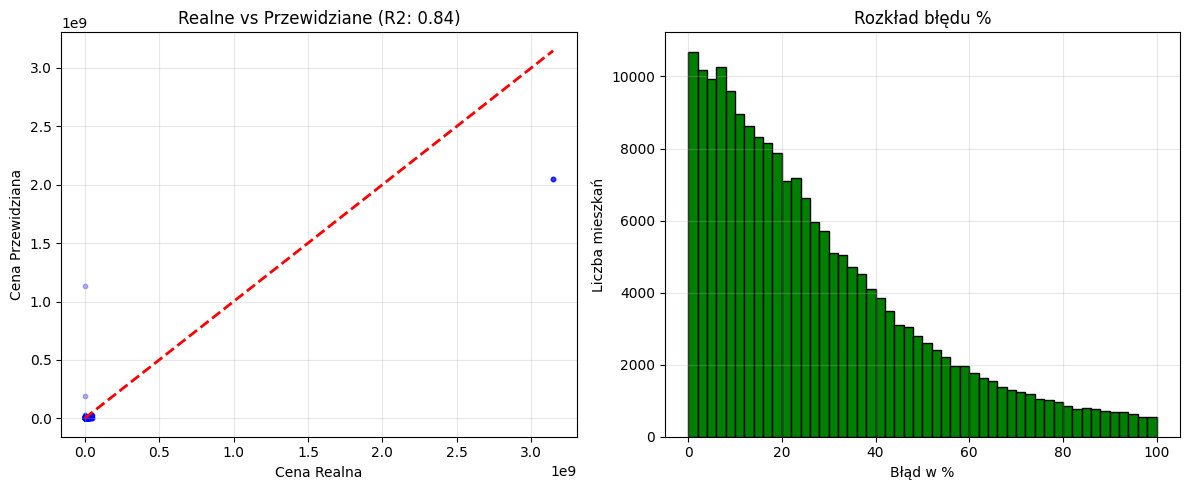

------------------------------
WYNIKI ANALIZY:
R2 Score:      0.8429 (im bliżej 1, tym lepiej)
MAE:           174,380.20 PLN (średnio o tyle zł się mylisz)
MAPE:          51072757236739424256.00% (średnio o tyle % się mylisz)
Mediana błędu: 77,096.19 PLN
------------------------------


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, median_absolute_error

# params
mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
medae = median_absolute_error(y_test, predictions)

# Błąd procentowy dla każdego mieszkania
errors_pct = (np.abs(y_test - predictions) / y_test) * 100

plt.figure(figsize=(12, 5))

# zestawienie ceny realne vs przewidywana idelanie to x = y
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.3, color='blue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Realne vs Przewidziane (R2: {r2:.2f})')
plt.xlabel('Cena Realna')
plt.ylabel('Cena Przewidziana')
plt.grid(True, alpha=0.3)

# Histogram błędów w procentach
plt.subplot(1, 2, 2)
plt.hist(errors_pct, bins=50, color='green', edgecolor='black', range=(0, 100))
plt.title('Rozkład błędu %')
plt.xlabel('Błąd w %')
plt.ylabel('Liczba mieszkań')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. RAPORT W KONSOLI
print("-" * 30)
print(f"WYNIKI ANALIZY:")
print(f"R2 Score:      {r2:.4f} ")
print(f"MAE:           {mae:,.2f} PLN")
print(f"MAPE:          {mape:.2%} ")
print(f"Mediana błędu: {medae:,.2f} PLN")
print("-" * 30)

## Wnioski z Ewaluacji Modelu

- Skuteczność (R² = 0.84). Wysoka.

- Realny błąd Mediana = 77k, Średnia aż 174k, to trochę dużo ale na wykresie widać ewidentny wpływ outlierów także nie można robić modelu dla całego spektrum cen. 

- Błąd MAPE to wydaje się że znów pływ outlierów i cen równych 0 (dzielenie przez zero). Do usunięcia.

# Notatki
- *Model bazowy* - model bazowy przed wywaleniem outlierów ma średni błąd 174k z medianą błędu 77k, w kroku 2 wywalamy outliery

---

| Model | Outliery | Dane uczące | Target | Średni błąd | Mediana błędu | R² | MAPE | Liczba próbek | Czas trenowania |
|---|---|---|---|---|---|---|---|---|---|
| Las losowy | z | Zestaw I | `tran_cena_brutto` | 174k | 77k | 0.8429 | śmieciowy (div/0) | 1124077 | 2min39s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | ? | ? | ? | ? | ? | ? |

---

- Zestaw I: `features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac']`

# Model 1 - wywalamy outliery

In [ ]:
df = pd.read_parquet('data.parquet')

### Sprawdzamy outliery

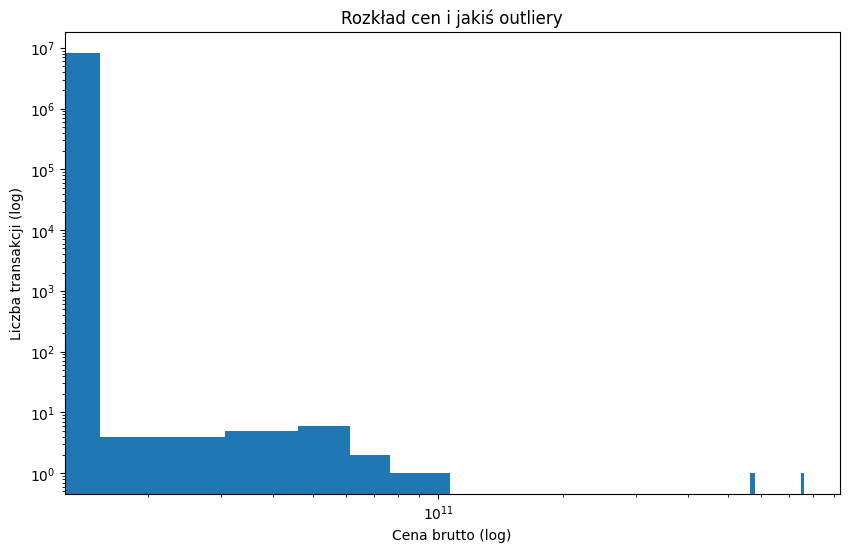

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['tran_cena_brutto'], bins=50, log=True) 
plt.xscale('log') 

plt.title("Rozkład cen i jakiś outliery")
plt.xlabel("Cena brutto (log)")
plt.ylabel("Liczba transakcji (log)")
plt.show()

In [ ]:
# Usuwamy ceny poniżej 100k i powyżej 3 mln, metraż poniżej 15m i powyżej 250m
df = df[(df['tran_cena_brutto'] > 100000) & (df['tran_cena_brutto'] < 3000000)]
df = df[(df['bud_pow_uzyt'] > 15) & (df['bud_pow_uzyt'] < 250)]

# Za sugestią chatbota dodaje też cenę za m2, ma to być niby bardziej miarodajne ale zaraz
# sobie to porównam, nie wiem czy to nie jest troche redundantne ale will see 
df['price_per_m2'] = df['tran_cena_brutto'] / df['bud_pow_uzyt']
df = df[(df['price_per_m2'] > 4000) & (df['price_per_m2'] < 40000)]

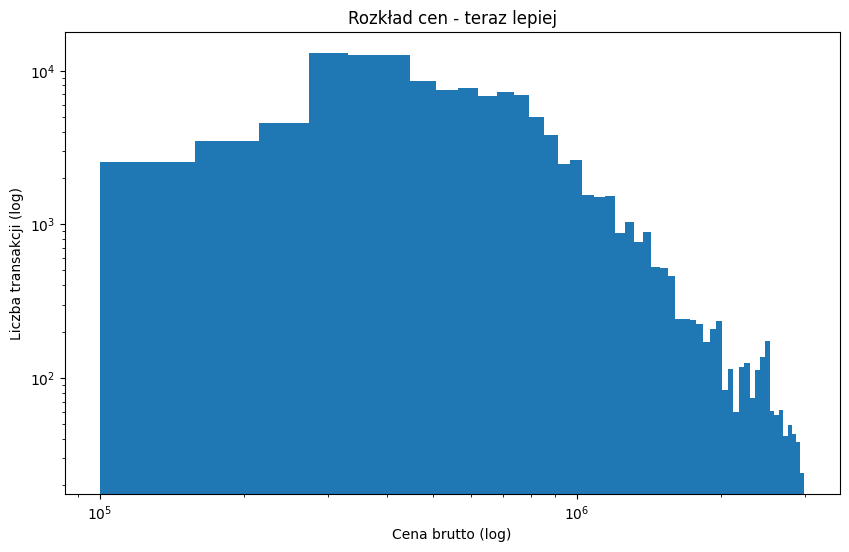

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['tran_cena_brutto'], bins=50, log=True) 
plt.xscale('log') 

plt.title("Rozkład cen - teraz lepiej")
plt.xlabel("Cena brutto (log)")
plt.ylabel("Liczba transakcji (log)")
plt.show()

### Zawężanie zestawu uczącego

In [ ]:
#interesją nas tylko gotowe lokale do zamieszkania na wolnym rynku, więc filtrujemy to sobie
df = df[
    (df['nier_rodzaj'] == 'nieruchomoscLokalowa') & 
    (df['bud_rodzaj'] == 'mieszkalny') & 
    (df['tran_rodzaj_trans'] == 'wolnyRynek')
]

### Konwersja typów danyych

In [ ]:
df = df.dropna(subset=['dok_data']) # Usuwamy wiersze bez daty

# Wyciągamy rok i miesiąc jako oddzielne liczby
df['rok'] = df['dok_data'].dt.year
df['miesiac'] = df['dok_data'].dt.month

In [ ]:
df['teryt'] = df['teryt'].astype('int')

df['RynekPierwotny'] = np.where(df['tran_rodzaj_rynku'] == 'pierwotny', 1, 0)

df['Sprzedajacy'] = np.where(df['tran_sprzedajacy'] == 'osobaFizyczna', 0,
                            np.where(df['tran_sprzedajacy'] == 'osobaPrawna', 1,
                                     np.where(df['tran_sprzedajacy'] == 'JednostkaSamorzaduTerytorialnego', 2,
                                              np.where(df['tran_sprzedajacy'] == 'skarbPanstwa', 3, 4)))) 

df['rok'] = df['rok'].astype('int')
df['miesiac'] = df['miesiac'].astype('int')

df = df.drop(columns=['tran_rodzaj_rynku', 'tran_sprzedajacy'])

In [ ]:
features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac']
X = df[features]
y = df['tran_cena_brutto']

In [ ]:
X.info()
X.nunique()
X.head()

<class 'pandas.DataFrame'>
Index: 47023 entries, 8401 to 8210423
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bud_pow_uzyt    47023 non-null  float64
 1   RynekPierwotny  47023 non-null  int64  
 2   Sprzedajacy     47023 non-null  int64  
 3   teryt           47023 non-null  int64  
 4   rok             47023 non-null  int64  
 5   miesiac         47023 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 2.5 MB


,bud_pow_uzyt,RynekPierwotny,Sprzedajacy,teryt,rok,miesiac
8401,142.70,0,0,1432,2015,2
23274,161.25,0,0,1463,2018,2
76869,24.00,0,0,1429,2014,12
88002,161.25,0,0,1463,2018,2
93692,38.00,0,1,1210,2013,8


### Przygotowanie modelu

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

In [ ]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

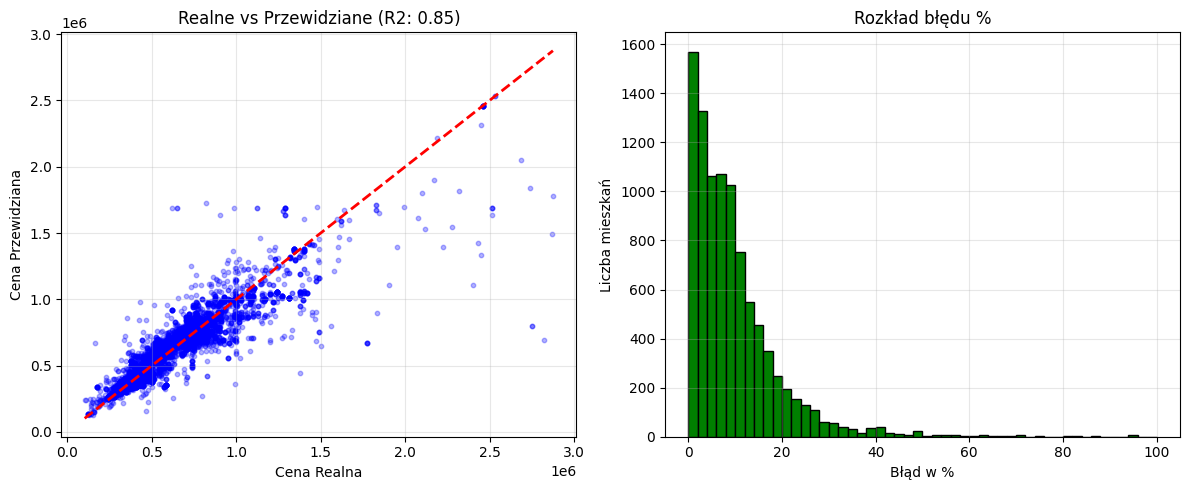

------------------------------
WYNIKI ANALIZY:
R2 Score:      0.8526 (im bliżej 1, tym lepiej)
MAE:           58,425.79 PLN (średnio o tyle zł się mylisz)
MAPE:          9.78% (średnio o tyle % się mylisz)
Mediana błędu: 33,208.36 PLN
------------------------------


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, median_absolute_error

# params
mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
medae = median_absolute_error(y_test, predictions)

# Błąd procentowy dla każdego mieszkania
errors_pct = (np.abs(y_test - predictions) / y_test) * 100

plt.figure(figsize=(12, 5))

# zestawienie ceny realne vs przewidywana idelanie to x = y
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.3, color='blue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Realne vs Przewidziane (R2: {r2:.2f})')
plt.xlabel('Cena Realna')
plt.ylabel('Cena Przewidziana')
plt.grid(True, alpha=0.3)

# Histogram błędów w procentach
plt.subplot(1, 2, 2)
plt.hist(errors_pct, bins=50, color='green', edgecolor='black', range=(0, 100))
plt.title('Rozkład błędu %')
plt.xlabel('Błąd w %')
plt.ylabel('Liczba mieszkań')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("-" * 30)
print(f"WYNIKI ANALIZY:")
print(f"R2 Score:      {r2:.4f}")
print(f"MAE:           {mae:,.2f} PLN")
print(f"MAPE:          {mape:.2%}")
print(f"Mediana błędu: {medae:,.2f} PLN")
print("-" * 30)

# Notatki
- *Model bazowy* - model bazowy przed wywaleniem outlierów ma średni błąd 174k z medianą błędu 77k, w kroku 2 wywalamy outliery
- *Model I* - po wywaleniu outlierów średni błąd modelu spadł do 58k i mediana 33k. Błąd to mniej niż 10%. Trochę mało próbek teraz mamy, ale wynika to z tego, że wiele recordów nie ma daty a jest to kluczowy parametr, któego raczej nie mogę zamienić na unknown albo zrobić jakieś mądre fillna. Spróbuję jednak poeksperymentować z czyszczeniem datasetu, może uda mi się uzyskać większą liczbę próbek. 

---

| Model | Outliery | Dane uczące | Target | Średni błąd | Mediana błędu | R² | MAPE | Liczba próbek | Czas trenowania |
|---|---|---|---|---|---|---|---|---|---|
| Las losowy | z | Zestaw I | `tran_cena_brutto` | 174k | 77k | 0.8429 | śmieciowy (div/0) | 1124077 | 2min39s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 58k | 33k | 0.8526 | 9.78% | 47023 | 2,4s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | ? | ? | ? | ? | ? | ? |

---

- Zestaw I: `features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac']`

# Model 2 - dostosowanie filtracji danych wejściowych

In [ ]:
df = pd.read_parquet('data.parquet')

### Wywalamy outliery

In [ ]:
# Usuwamy ceny poniżej 100k i powyżej 2 mln, metraż poniżej 15m i powyżej 250m
df = df[(df['tran_cena_brutto'] > 100000) & (df['tran_cena_brutto'] < 1400000)]
df = df[(df['bud_pow_uzyt'] > 15) & (df['bud_pow_uzyt'] < 240)]
    
# Za sugestią chatbota dodaje też cenę za m2, ma to być niby bardziej miarodajne ale zaraz
# sobie to porównam, nie wiem czy to nie jest troche redundantne ale will see 
df['price_per_m2'] = df['tran_cena_brutto'] / df['bud_pow_uzyt']
df = df[(df['price_per_m2'] > 4000) & (df['price_per_m2'] < 32000)]

### Zawężanie zestawu uczącego

In [ ]:
#interesją nas tylko gotowe lokale do zamieszkania na wolnym rynku, więc filtrujemy to sobie
df = df[
    (df['nier_rodzaj'] == 'nieruchomoscLokalowa') & 
    (df['bud_rodzaj'] == 'mieszkalny') & 
    (df['tran_rodzaj_trans'] == 'wolnyRynek')
]

In [ ]:
# Zamiast usuwać wiersze ustawie nową kategorię dla braków
df['tran_rodzaj_rynku'] = df['tran_rodzaj_rynku'].fillna('nieznany')
df['tran_sprzedajacy'] = df['tran_sprzedajacy'].fillna('nieznany')

# Dropna tylko dla Ceny, Metrażu i daty
df = df.dropna(subset=['tran_cena_brutto', 'bud_pow_uzyt', 'dok_data'])

### Konwersja typów danyych

In [ ]:
features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'dok_data']

# Wyciągamy rok i miesiąc jako oddzielne liczby
df['rok'] = df['dok_data'].dt.year
df['miesiac'] = df['dok_data'].dt.month

In [ ]:
df['teryt'] = df['teryt'].astype('int')

df['RynekPierwotny'] = np.where(df['tran_rodzaj_rynku'] == 'pierwotny', 1, 0)

df['Sprzedajacy'] = np.where(df['tran_sprzedajacy'] == 'osobaFizyczna', 0,
                            np.where(df['tran_sprzedajacy'] == 'osobaPrawna', 1,
                                     np.where(df['tran_sprzedajacy'] == 'JednostkaSamorzaduTerytorialnego', 2,
                                              np.where(df['tran_sprzedajacy'] == 'skarbPanstwa', 3, 4)))) 

df['rok'] = df['rok'].astype('int')
df['miesiac'] = df['miesiac'].astype('int')

df = df.drop(columns=['tran_rodzaj_rynku', 'tran_sprzedajacy'])

In [ ]:
features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac']
X = df[features]
y = df['tran_cena_brutto']

In [ ]:
X.info()
X.nunique()
X.head()

<class 'pandas.DataFrame'>
Index: 46239 entries, 8401 to 8190922
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bud_pow_uzyt    46239 non-null  float64
 1   RynekPierwotny  46239 non-null  int64  
 2   Sprzedajacy     46239 non-null  int64  
 3   teryt           46239 non-null  int64  
 4   rok             46239 non-null  int64  
 5   miesiac         46239 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 2.5 MB


,bud_pow_uzyt,RynekPierwotny,Sprzedajacy,teryt,rok,miesiac
8401,142.70,0,0,1432,2015,2
76869,24.00,0,0,1429,2014,12
93692,38.00,0,1,1210,2013,8
94197,101.05,1,0,3021,2021,11
94255,81.20,1,1,3021,2019,11


### Przygotowanie modelu

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

In [ ]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
predictions = model.predict(X_test)
error = mean_absolute_error(y_test, predictions)

print(f"Średni błąd modelu: {error:.2f} PLN")

Średni błąd modelu: 45543.34 PLN


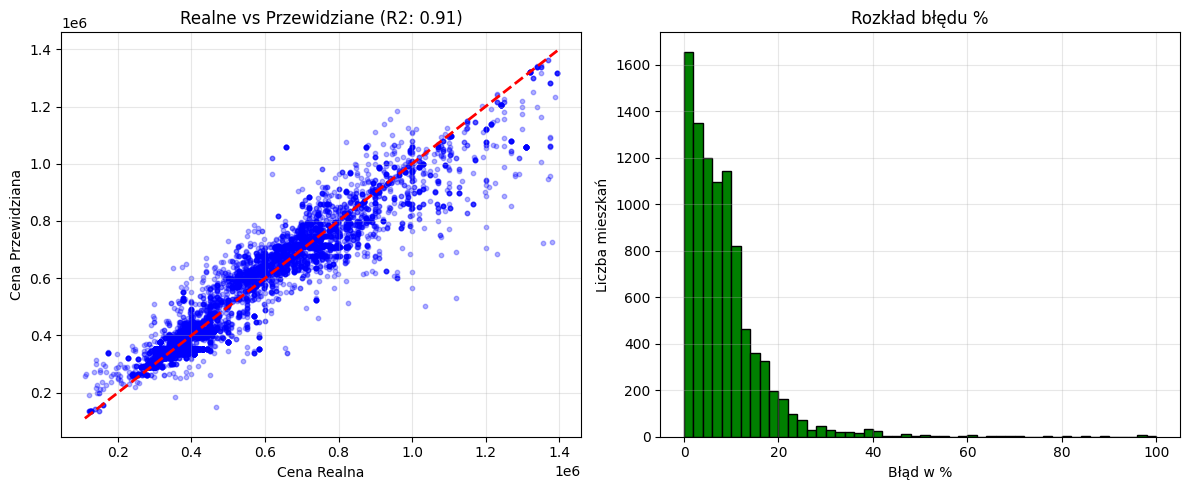

------------------------------
WYNIKI ANALIZY:
R2 Score:      0.9121 (im bliżej 1, tym lepiej)
MAE:           45,543.34 PLN (średnio o tyle zł się mylisz)
MAPE:          8.53% (średnio o tyle % się mylisz)
Mediana błędu: 30,266.54 PLN
------------------------------


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, median_absolute_error

# params
mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
medae = median_absolute_error(y_test, predictions)

# Błąd procentowy dla każdego mieszkania
errors_pct = (np.abs(y_test - predictions) / y_test) * 100

plt.figure(figsize=(12, 5))

# zestawienie ceny realne vs przewidywana idelanie to x = y
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.3, color='blue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Realne vs Przewidziane (R2: {r2:.2f})')
plt.xlabel('Cena Realna')
plt.ylabel('Cena Przewidziana')
plt.grid(True, alpha=0.3)

# Histogram błędów w procentach
plt.subplot(1, 2, 2)
plt.hist(errors_pct, bins=50, color='green', edgecolor='black', range=(0, 100))
plt.title('Rozkład błędu %')
plt.xlabel('Błąd w %')
plt.ylabel('Liczba mieszkań')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. RAPORT W KONSOLI
print("-" * 30)
print(f"WYNIKI ANALIZY:")
print(f"R2 Score:      {r2:.4f} ")
print(f"MAE:           {mae:,.2f} PLN ")
print(f"MAPE:          {mape:.2%} ")
print(f"Mediana błędu: {medae:,.2f} PLN")
print("-" * 30)

# Notatki
- *Model bazowy** - model bazowy przed wywaleniem outlierów ma średni błąd 174k z medianą błędu 77k, w kroku 2 wywalamy outliery
- **Model I** - po wywaleniu outlierów średni błąd modelu spadł do 58k i mediana 33k. Błąd to mniej niż 10%. Trochę mało próbek teraz mamy, może spróbuje dostarczć ich trochę więcej.
- **Model II** - w tym kroku wykonałem troche testów. Na zwiększeniu limitu ceny nieruchomości do 4mln udało się zyskać niespełna 50 recordów, a parametry błędu zmieniły się na niekożyść, więc całkowicie rezygnuje z tej strategii zwiększanai liczby próbek. Po odcięciu cen nieruchomości powyżej 2mln (dla kontekstu w poprzednim kroku było to 3mln), udało się nieco podciągnąć wyniki modelu, efekty tej operacji widać tabeli poniżej w wierszu 4. Finalnie udało mi się uzyskać następujące zestawienie zmiennych filtrujących, odcinających outliery, które gwarantuje najlepsze wyniki przedstawione w wierszu 5 tabeli:
    - Cena — zakres: `100k < tran_cena_brutto < 1 400k PLN`
    - Metraż — zakres: `15 < bud_pow_uzyt < 240 m²`
    - Cena za m² — zakres: `4 000 < price_per_m2 < 32 000 PLN/m²`
W następnym kroku spróbuję jednak nieco rozszerzyć te zekresy, dodając jednocześnie filtracje tylko dla danych z roku 2025.


---

| Model | Outliery | Dane uczące | Target | Średni błąd | Mediana błędu | R² | MAPE | Liczba próbek | Czas trenowania |
|---|---|---|---|---|---|---|---|---|---|
| Las losowy | z | Zestaw I | `tran_cena_brutto` | 174k | 77k | 0.8429 | śmieciowy (div/0) | 1124077 | 2min39s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 58k | 33k | 0.8526 | 9.78% | 47023 | 2,4s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 61k | 33k | 0.8401 | 10.17% | 47068 | 2,3s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 52k | 31k | 0.8726 | 9.27% | 46844 | 2,2s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 45k | 30k | 0.9121 | 8.53% | 46239 | 2,1s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | ? | ? | ? | ? | ? | ? |




---

- Zestaw I: `features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac']`

# Model 3 - uczenie na danych od roku 2025

In [ ]:
df = pd.read_parquet('data.parquet')

### Wywalamy outliery

In [ ]:
# Usuwamy ceny poniżej 100k i powyżej 1,6 mln, metraż poniżej 15m i powyżej 250m
df = df[(df['tran_cena_brutto'] > 100000) & (df['tran_cena_brutto'] < 1400000)]
df = df[(df['bud_pow_uzyt'] > 15) & (df['bud_pow_uzyt'] < 240)]
    
# Za sugestią chatbota dodaje też cenę za m2, ma to być niby bardziej miarodajne ale zaraz
# sobie to porównam, nie wiem czy to nie jest troche redundantne ale will see 
df['price_per_m2'] = df['tran_cena_brutto'] / df['bud_pow_uzyt']
df = df[(df['price_per_m2'] > 4000) & (df['price_per_m2'] < 32000)]

# dane dla lat >= 2025
df = df[(df['dok_data'].dt.year > 2024)]

### Zawężanie zestawu uczącego

In [ ]:
#interesją nas tylko gotowe lokale do zamieszkania na wolnym rynku, więc filtrujemy to sobie
df = df[
    (df['nier_rodzaj'] == 'nieruchomoscLokalowa') & 
    (df['bud_rodzaj'] == 'mieszkalny') & 
    (df['tran_rodzaj_trans'] == 'wolnyRynek')
]

In [ ]:
# Zamiast usuwać wiersze ustawie nową kategorię dla braków
df['tran_rodzaj_rynku'] = df['tran_rodzaj_rynku'].fillna('nieznany')
df['tran_sprzedajacy'] = df['tran_sprzedajacy'].fillna('nieznany')

# Dropna tylko dla Ceny, Metrażu i daty
df = df.dropna(subset=['tran_cena_brutto', 'bud_pow_uzyt', 'dok_data'])

### Konwersja typów danyych

In [ ]:
features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'dok_data']

# Wyciągamy rok i miesiąc jako oddzielne liczby
df['rok'] = df['dok_data'].dt.year
df['miesiac'] = df['dok_data'].dt.month

In [ ]:
df['teryt'] = df['teryt'].astype('int')

df['RynekPierwotny'] = np.where(df['tran_rodzaj_rynku'] == 'pierwotny', 1, 0)

df['Sprzedajacy'] = np.where(df['tran_sprzedajacy'] == 'osobaFizyczna', 0,
                            np.where(df['tran_sprzedajacy'] == 'osobaPrawna', 1,
                                     np.where(df['tran_sprzedajacy'] == 'JednostkaSamorzaduTerytorialnego', 2,
                                              np.where(df['tran_sprzedajacy'] == 'skarbPanstwa', 3, 4)))) 

df['rok'] = df['rok'].astype('int')
df['miesiac'] = df['miesiac'].astype('int')

df = df.drop(columns=['tran_rodzaj_rynku', 'tran_sprzedajacy'])

In [ ]:
features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac']
X = df[features]
y = df['tran_cena_brutto']

In [ ]:
X.info()
X.nunique()
X.head()

<class 'pandas.DataFrame'>
Index: 4744 entries, 709927 to 8181707
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bud_pow_uzyt    4744 non-null   float64
 1   RynekPierwotny  4744 non-null   int64  
 2   Sprzedajacy     4744 non-null   int64  
 3   teryt           4744 non-null   int64  
 4   rok             4744 non-null   int64  
 5   miesiac         4744 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 259.4 KB


,bud_pow_uzyt,RynekPierwotny,Sprzedajacy,teryt,rok,miesiac
709927,125.40,1,1,1262,2025,12
1058501,149.03,0,0,1210,2025,6
1096586,129.89,0,0,1210,2025,2
1220543,127.63,0,0,1210,2025,4
1378698,118.28,1,1,1262,2025,12


### Przygotowanie modelu

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

In [ ]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
predictions = model.predict(X_test)
error = mean_absolute_error(y_test, predictions)

print(f"Średni błąd modelu: {error:.2f} PLN")

Średni błąd modelu: 55947.67 PLN


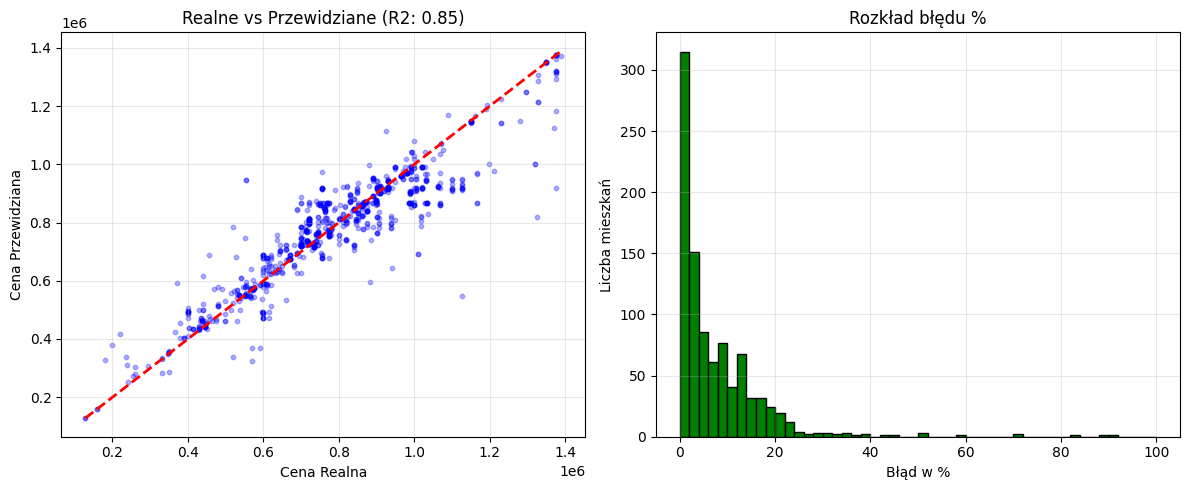

------------------------------
WYNIKI ANALIZY:
R2 Score:      0.8492 (im bliżej 1, tym lepiej)
MAE:           55,947.67 PLN (średnio o tyle zł się mylisz)
MAPE:          7.40% (średnio o tyle % się mylisz)
Mediana błędu: 30,581.56 PLN
------------------------------


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, median_absolute_error

# params
mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
medae = median_absolute_error(y_test, predictions)

# Błąd procentowy dla każdego mieszkania
errors_pct = (np.abs(y_test - predictions) / y_test) * 100

plt.figure(figsize=(12, 5))

# zestawienie ceny realne vs przewidywana idelanie to x = y
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.3, color='blue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Realne vs Przewidziane (R2: {r2:.2f})')
plt.xlabel('Cena Realna')
plt.ylabel('Cena Przewidziana')
plt.grid(True, alpha=0.3)

# Histogram błędów w procentach
plt.subplot(1, 2, 2)
plt.hist(errors_pct, bins=50, color='green', edgecolor='black', range=(0, 100))
plt.title('Rozkład błędu %')
plt.xlabel('Błąd w %')
plt.ylabel('Liczba mieszkań')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. RAPORT W KONSOLI
print("-" * 30)
print(f"WYNIKI ANALIZY:")
print(f"R2 Score:      {r2:.4f}")
print(f"MAE:           {mae:,.2f} PLN")
print(f"MAPE:          {mape:.2%} ")
print(f"Mediana błędu: {medae:,.2f} PLN")
print("-" * 30)

# Notatki
- **Model Bazowy** - model bazowy przed wywaleniem outlierów ma średni błąd 174k z medianą błędu 77k, w kroku 2 wywalamy outliery
- **Model I** - po wywaleniu outlierów średni błąd modelu spadł do 58k i mediana 33k. Błąd to mniej niż 10%. Trochę mało próbek teraz mamy, może spróbuje dostarczć ich trochę więcej.
- **Model II** - w tym kroku wykonałem troche testów. Na zwiększeniu limitu ceny nieruchomości do 4mln udało się zyskać niespełna 50 recordów, a parametry błędu zmieniły się na niekożyść, więc całkowicie rezygnuje z tej strategii zwiększanai liczby próbek. Po odcięciu cen nieruchomości powyżej 2mln (dla kontekstu w poprzednim kroku było to 3mln), udało się nieco podciągnąć wyniki modelu, efekty tej operacji widać tabeli poniżej w wierszu 4. Finalnie udało mi się uzyskać następujące zestawienie zmiennych filtrujących, odcinających outliery, które gwarantuje najlepsze wyniki przedstawione w wierszu 5 tabeli:
    - Cena — zakres: `100k < tran_cena_brutto < 1 400k PLN`
    - Metraż — zakres: `15 < bud_pow_uzyt < 240 m²`
    - Cena za m² — zakres: `4 000 < price_per_m2 < 32 000 PLN/m²`

    W następnym kroku spróbuję jednak nieco rozszerzyć te zekresy, dodając jednocześnie filtracje tylko dla danych z roku 2025.
- **Model III** - Po filtracji od roku 2025, ubyło sporo próbek, średni błąd trochę wzrósł natomiast błąd procenotwy zmalał do 7.40%. Spróbuję jeszcze potestować inne modele ML.



---

| Model | Outliery | Dane uczące | Target | Średni błąd | Mediana błędu | R² | MAPE | Liczba próbek | Czas trenowania |
|---|---|---|---|---|---|---|---|---|---|
| Las losowy | z | Zestaw I | `tran_cena_brutto` | 174k | 77k | 0.8429 | śmieciowy (div/0) | 1124077 | 2min39s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 58k | 33k | 0.8526 | 9.78% | 47023 | 2,4s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 61k | 33k | 0.8401 | 10.17% | 47068 | 2,3s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 52k | 31k | 0.8726 | 9.27% | 46844 | 2,2s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 45k | 30k | 0.9121 | 8.53% | 46239 | 2,1s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 56k | 30k | 0.8492 | 7.40% | 4703 | 0,3s |
| XGBoost | bez | Zestaw I | `tran_cena_brutto` | ? | ? | ? | ? | ? | ? |





---

- Zestaw I: `features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac']`

# Model 4 - Wykożystanie XGBoost

In [ ]:
df = pd.read_parquet('data.parquet')

### Wywalamy outliery

In [ ]:
# Usuwamy ceny poniżej 100k i powyżej 1,6 mln, metraż poniżej 15m i powyżej 250m
df = df[(df['tran_cena_brutto'] > 100000) & (df['tran_cena_brutto'] < 1400000)]
df = df[(df['bud_pow_uzyt'] > 15) & (df['bud_pow_uzyt'] < 240)]
    
# Za sugestią chatbota dodaje też cenę za m2, ma to być niby bardziej miarodajne ale zaraz
# sobie to porównam, nie wiem czy to nie jest troche redundantne ale will see 
df['price_per_m2'] = df['tran_cena_brutto'] / df['bud_pow_uzyt']
df = df[(df['price_per_m2'] > 4000) & (df['price_per_m2'] < 32000)]

### Zawężanie zestawu uczącego

In [ ]:
#interesją nas tylko gotowe lokale do zamieszkania na wolnym rynku, więc filtrujemy to sobie
df = df[
    (df['nier_rodzaj'] == 'nieruchomoscLokalowa') & 
    (df['bud_rodzaj'] == 'mieszkalny') & 
    (df['tran_rodzaj_trans'] == 'wolnyRynek')
]

In [ ]:
# Zamiast usuwać wiersze ustawie nową kategorię dla braków
df['tran_rodzaj_rynku'] = df['tran_rodzaj_rynku'].fillna('nieznany')
df['tran_sprzedajacy'] = df['tran_sprzedajacy'].fillna('nieznany')

# Dropna tylko dla Ceny, Metrażu i daty
df = df.dropna(subset=['tran_cena_brutto', 'bud_pow_uzyt', 'dok_data'])

### Konwersja typów danyych

In [ ]:
features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'dok_data']

# Wyciągamy rok i miesiąc jako oddzielne liczby
df['rok'] = df['dok_data'].dt.year
df['miesiac'] = df['dok_data'].dt.month

In [ ]:
df['teryt'] = df['teryt'].astype('int')

df['RynekPierwotny'] = np.where(df['tran_rodzaj_rynku'] == 'pierwotny', 1, 0)

df['Sprzedajacy'] = np.where(df['tran_sprzedajacy'] == 'osobaFizyczna', 0,
                            np.where(df['tran_sprzedajacy'] == 'osobaPrawna', 1,
                                     np.where(df['tran_sprzedajacy'] == 'JednostkaSamorzaduTerytorialnego', 2,
                                              np.where(df['tran_sprzedajacy'] == 'skarbPanstwa', 3, 4)))) 

df['rok'] = df['rok'].astype('int')
df['miesiac'] = df['miesiac'].astype('int')

df = df.drop(columns=['tran_rodzaj_rynku', 'tran_sprzedajacy'])

In [ ]:
features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac']
X = df[features]
y = df['tran_cena_brutto']

In [ ]:
X.info()
X.nunique()
X.head()

<class 'pandas.DataFrame'>
Index: 46239 entries, 8401 to 8190922
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bud_pow_uzyt    46239 non-null  float64
 1   RynekPierwotny  46239 non-null  int64  
 2   Sprzedajacy     46239 non-null  int64  
 3   teryt           46239 non-null  int64  
 4   rok             46239 non-null  int64  
 5   miesiac         46239 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 2.5 MB


,bud_pow_uzyt,RynekPierwotny,Sprzedajacy,teryt,rok,miesiac
8401,142.70,0,0,1432,2015,2
76869,24.00,0,0,1429,2014,12
93692,38.00,0,1,1210,2013,8
94197,101.05,1,0,3021,2021,11
94255,81.20,1,1,3021,2019,11


### Przygotowanie modelu

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=8, 
    n_jobs=-1, 
    random_state=42,
    objective='reg:squarederror'
)

In [ ]:
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [ ]:
predictions = xgb_model.predict(X_test)
error = mean_absolute_error(y_test, predictions)

joblib.dump(xgb_model, 'model.joblib')
model_metadata = {
    'features': ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac'],
    'target': 'tran_cena_brutto'
}
joblib.dump(model_metadata, 'model_metadata.joblib')

print(f"Średni błąd modelu: {error:.2f} PLN")

Średni błąd modelu: 36257.09 PLN


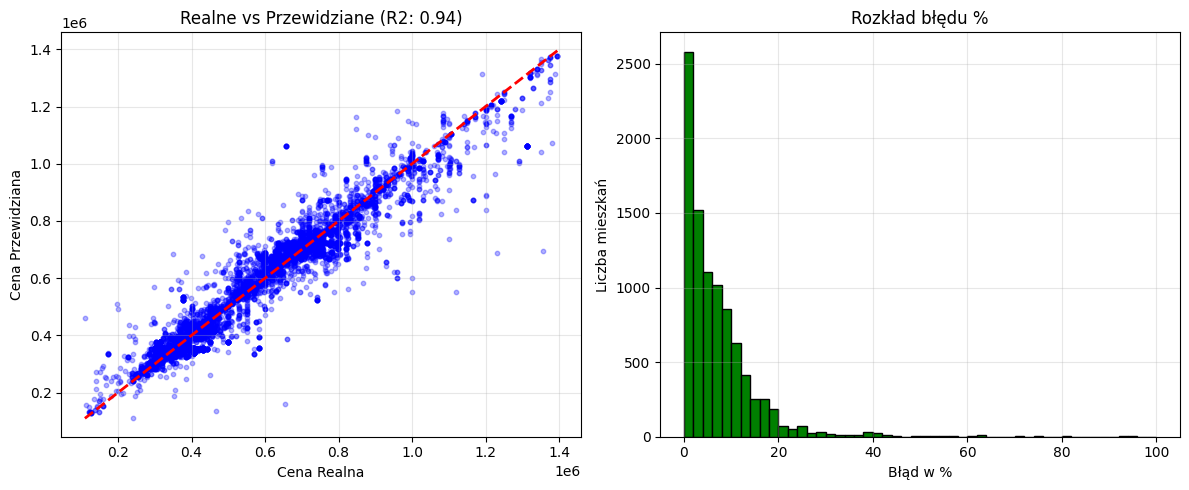

------------------------------
WYNIKI ANALIZY:
R2 Score:      0.9372
MAE:           36,257.09 PLN 
MAPE:          7.14% 
Mediana błędu: 23,688.19 PLN
------------------------------


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, median_absolute_error

# params
mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
medae = median_absolute_error(y_test, predictions)

# Błąd procentowy dla każdego mieszkania
errors_pct = (np.abs(y_test - predictions) / y_test) * 100

plt.figure(figsize=(12, 5))

# zestawienie ceny realne vs przewidywana idelanie to x = y
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.3, color='blue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Realne vs Przewidziane (R2: {r2:.2f})')
plt.xlabel('Cena Realna')
plt.ylabel('Cena Przewidziana')
plt.grid(True, alpha=0.3)

# Histogram błędów w procentach
plt.subplot(1, 2, 2)
plt.hist(errors_pct, bins=50, color='green', edgecolor='black', range=(0, 100))
plt.title('Rozkład błędu %')
plt.xlabel('Błąd w %')
plt.ylabel('Liczba mieszkań')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. RAPORT W KONSOLI
print("-" * 30)
print(f"WYNIKI ANALIZY:")
print(f"R2 Score:      {r2:.4f}")
print(f"MAE:           {mae:,.2f} PLN ")
print(f"MAPE:          {mape:.2%} ")
print(f"Mediana błędu: {medae:,.2f} PLN")
print("-" * 30)

# Notatki
- **Model bazowy** - model bazowy przed wywaleniem outlierów ma średni błąd 174k z medianą błędu 77k, w kroku 2 wywalamy outliery
- **Model I** - po wywaleniu outlierów średni błąd modelu spadł do 58k i mediana 33k. Błąd to mniej niż 10%. Trochę mało próbek teraz mamy, może spróbuje dostarczć ich trochę więcej.
- **Model II** - w tym kroku wykonałem troche testów. Na zwiększeniu limitu ceny nieruchomości do 4mln udało się zyskać niespełna 50 recordów, a parametry błędu zmieniły się na niekożyść, więc całkowicie rezygnuje z tej strategii zwiększanai liczby próbek. Po odcięciu cen nieruchomości powyżej 2mln (dla kontekstu w poprzednim kroku było to 3mln), udało się nieco podciągnąć wyniki modelu, efekty tej operacji widać tabeli poniżej w wierszu 4. Finalnie udało mi się uzyskać następujące zestawienie zmiennych filtrujących, odcinających outliery, które gwarantuje najlepsze wyniki przedstawione w wierszu 5 tabeli:
    - Cena — zakres: `100k < tran_cena_brutto < 1 400k PLN`
    - Metraż — zakres: `15 < bud_pow_uzyt < 240 m²`
    - Cena za m² — zakres: `4 000 < price_per_m2 < 32 000 PLN/m²`

    W następnym kroku spróbuję jednak nieco rozszerzyć te zekresy, dodając jednocześnie filtracje tylko dla danych z roku 2025.
- **Model III** - Po filtracji od roku 2025, ubyło sporo próbek, średni błąd trochę wzrósł natomiast błąd procenotwy zmalał do 7.40%. Spróbuję jeszcze potestować inne modele ML.
- **Mdel IV** - Po użyciu modelu XGBoost, praktycznie wszystkie wskaźniki efektywności udało się znacznie poprawić. Ale znalazłem jescze jedną super informacje. Okazuje się, że zmienna 'teryt' zawiera w sobie informacje o typie gminy! Zmienna teryt to 7-cyfrowy kokd, gdzie statnia cyfra mówi nam o typie gminy, co jest bezpośrednim wskaźnikiem „miejskości”:

    1 – gmina miejska (duże i średnie miasta).

    2 – gmina wiejska.
    
    3 – gmina miejsko-wiejska.
    
    8/9 – dzielnice (np. Warszawy).

    Dla modelu to ważne dane i myślę, że może to pomóc w uczeniu modelu. Dodam to do danych uczących i zobaczymy co z tego wyjdzie.


---

| Model | Outliery | Dane uczące | Target | Średni błąd | Mediana błędu | R² | MAPE | Liczba próbek | Czas trenowania |
|---|---|---|---|---|---|---|---|---|---|
| Las losowy | z | Zestaw I | `tran_cena_brutto` | 174k | 77k | 0.8429 | śmieciowy (div/0) | 1124077 | 2min39s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 58k | 33k | 0.8526 | 9.78% | 47023 | 2,4s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 61k | 33k | 0.8401 | 10.17% | 47068 | 2,3s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 52k | 31k | 0.8726 | 9.27% | 46844 | 2,2s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 45k | 30k | 0.9121 | 8.53% | 46239 | 2,1s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 56k | 30k | 0.8492 | 7.40% | 4703  | 0,3s |
| XGBoost    | bez | Zestaw I | `tran_cena_brutto` | 36k | 23k | 0.9372 | 7.14% | 46239 | 2,4s |
| XGBoost    | bez | Zestaw II | `tran_cena_brutto` | ? | ? | ? | ? | ? | ? |

---

- Zestaw I: `features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac']`
- Zestaw II: `features = features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'rok', 'miesiac', 'gmina', 
    'czy_warszawa']`

# Model 5 - Wykożystanie XGBoost ze wstępną kategoryzacją parametrów

In [ ]:
df = pd.read_parquet('data.parquet')

### Wywalamy outliery

In [ ]:
# Usuwamy ceny poniżej 100k i powyżej 1,6 mln, metraż poniżej 15m i powyżej 250m
df = df[(df['tran_cena_brutto'] > 100000) & (df['tran_cena_brutto'] < 1200000)]
df = df[(df['bud_pow_uzyt'] > 15) & (df['bud_pow_uzyt'] < 240)]
    
# Za sugestią chatbota dodaje też cenę za m2, ma to być niby bardziej miarodajne ale zaraz
# sobie to porównam, nie wiem czy to nie jest troche redundantne ale will see 
df['price_per_m2'] = df['tran_cena_brutto'] / df['bud_pow_uzyt']
df = df[(df['price_per_m2'] > 4000) & (df['price_per_m2'] < 32000)]

### Zawężanie zestawu uczącego

In [ ]:
#interesją nas tylko gotowe lokale do zamieszkania na wolnym rynku, więc filtrujemy to sobie
df = df[
    (df['nier_rodzaj'] == 'nieruchomoscLokalowa') & 
    (df['bud_rodzaj'] == 'mieszkalny') & 
    (df['tran_rodzaj_trans'] == 'wolnyRynek')
]

In [ ]:
# Zamiast usuwać wiersze ustawie nową kategorię dla braków
df['tran_rodzaj_rynku'] = df['tran_rodzaj_rynku'].fillna('nieznany')
df['tran_sprzedajacy'] = df['tran_sprzedajacy'].fillna('nieznany')

# Dropna tylko dla Ceny, Metrażu i daty
df = df.dropna(subset=['tran_cena_brutto', 'bud_pow_uzyt', 'dok_data'])

### Konwersja typów danyych

In [ ]:
# Zmieniamy sobei na stringa i uzupełniamy do 7 znaków
df['teryt_str'] = df['teryt'].astype(str)

# Typ gminy czy to miasto, czy wieś
df['typ_gminy'] = df['teryt_str'].str[-1].astype('category')

# Czy to Warszawa? (Warszawa ma kod zaczynający się od 1465)
df['czy_warszawa'] = df['teryt_str'].str.startswith('1465').astype(int)

In [ ]:
mapa_typow_gmin = {
    '1': 'Gmina miejska (Miasto)',
    '2': 'Gmina wiejska (Wieś)',
    '3': 'Gmina miejsko-wiejska',
    '4': 'Miasto w gminie miejsko-wiejskiej',
    '5': 'Obszar wiejski w gminie miejsko-wiejskiej',
    '8': 'Dzielnica Warszawy',
    '9': 'Delegatura miasta'
}

In [ ]:
df['gmina'] = df['typ_gminy'].map(mapa_typow_gmin)
df['gmina'] = df['gmina'].fillna('nieznany')
df['gmina'] = df['gmina'].astype('category')

In [ ]:
extra_features = ['gmina', 'czy_warszawa']

# Konwersja na kategorie
for col in ['bud_rodzaj', 'nier_prawo']:
    df[col] = df[col].astype('category')

In [ ]:
features = [
    'bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 
    'rok', 'miesiac', 'gmina', 
    'czy_warszawa'
]
# Wyciągamy rok i miesiąc jako oddzielne liczby
df['rok'] = df['dok_data'].dt.year
df['miesiac'] = df['dok_data'].dt.month

In [ ]:
df['teryt'] = df['teryt'].astype('int')

df['RynekPierwotny'] = np.where(df['tran_rodzaj_rynku'] == 'pierwotny', 1, 0)

df['Sprzedajacy'] = np.where(df['tran_sprzedajacy'] == 'osobaFizyczna', 0,
                            np.where(df['tran_sprzedajacy'] == 'osobaPrawna', 1,
                                     np.where(df['tran_sprzedajacy'] == 'JednostkaSamorzaduTerytorialnego', 2,
                                              np.where(df['tran_sprzedajacy'] == 'skarbPanstwa', 3, 4)))) 

df['rok'] = df['rok'].astype('int')
df['miesiac'] = df['miesiac'].astype('int')

df = df.drop(columns=['tran_rodzaj_rynku', 'tran_sprzedajacy'])

In [ ]:
X = df[features]
y = df['tran_cena_brutto']

In [ ]:
X.info()
X.nunique()
X.head()

<class 'pandas.DataFrame'>
Index: 45517 entries, 8401 to 8190922
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   bud_pow_uzyt    45517 non-null  float64 
 1   RynekPierwotny  45517 non-null  int64   
 2   Sprzedajacy     45517 non-null  int64   
 3   rok             45517 non-null  int64   
 4   miesiac         45517 non-null  int64   
 5   gmina           45517 non-null  category
 6   czy_warszawa    45517 non-null  int64   
dtypes: category(1), float64(1), int64(5)
memory usage: 2.5 MB


,bud_pow_uzyt,RynekPierwotny,Sprzedajacy,rok,miesiac,gmina,czy_warszawa
8401,142.70,0,0,2015,2,Gmina wiejska (Wieś),0
76869,24.00,0,0,2014,12,Delegatura miasta,0
93692,38.00,0,1,2013,8,nieznany,0
94197,101.05,1,0,2021,11,Gmina miejska (Miasto),0
94255,81.20,1,1,2019,11,Gmina miejska (Miasto),0


### Przygotowanie modelu

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=8, 
    n_jobs=-1, 
    random_state=42,
    enable_categorical=True,
    objective='reg:squarederror'
)

In [ ]:
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [ ]:
predictions = xgb_model.predict(X_test)
error = mean_absolute_error(y_test, predictions)

print(f"Średni błąd modelu: {error:.2f} PLN")

Średni błąd modelu: 36238.67 PLN


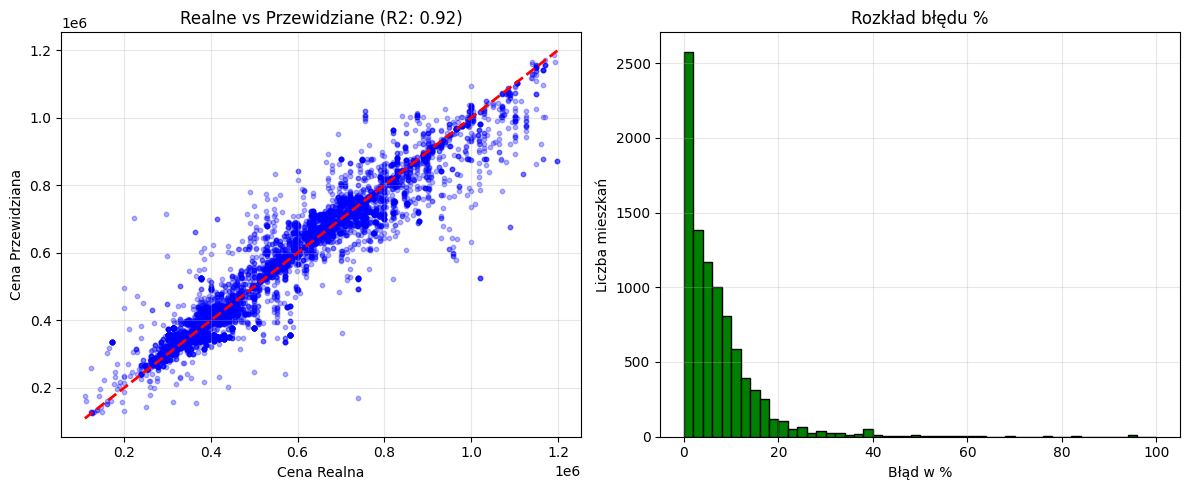

------------------------------
WYNIKI ANALIZY:
R2 Score:      0.9237
MAE:           36,238.67 PLN 
MAPE:          7.23% 
Mediana błędu: 23,097.34 PLN
------------------------------


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, median_absolute_error

# params
mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
medae = median_absolute_error(y_test, predictions)

# Błąd procentowy dla każdego mieszkania
errors_pct = (np.abs(y_test - predictions) / y_test) * 100

plt.figure(figsize=(12, 5))

# zestawienie ceny realne vs przewidywana idelanie to x = y
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.3, color='blue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Realne vs Przewidziane (R2: {r2:.2f})')
plt.xlabel('Cena Realna')
plt.ylabel('Cena Przewidziana')
plt.grid(True, alpha=0.3)

# Histogram błędów w procentach
plt.subplot(1, 2, 2)
plt.hist(errors_pct, bins=50, color='green', edgecolor='black', range=(0, 100))
plt.title('Rozkład błędu %')
plt.xlabel('Błąd w %')
plt.ylabel('Liczba mieszkań')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. RAPORT W KONSOLI
print("-" * 30)
print(f"WYNIKI ANALIZY:")
print(f"R2 Score:      {r2:.4f}")
print(f"MAE:           {mae:,.2f} PLN ")
print(f"MAPE:          {mape:.2%} ")
print(f"Mediana błędu: {medae:,.2f} PLN")
print("-" * 30)

# Notatki
- **Model Bazowy** - model bazowy przed wywaleniem outlierów ma średni błąd 174k z medianą błędu 77k, w kroku 2 wywalamy outliery
- **Model I** - po wywaleniu outlierów średni błąd modelu spadł do 58k i mediana 33k. Błąd to mniej niż 10%. Trochę mało próbek teraz mamy, może spróbuje dostarczć ich trochę więcej.
- **Model II** - w tym kroku wykonałem troche testów. Na zwiększeniu limitu ceny nieruchomości do 4mln udało się zyskać niespełna 50 recordów, a parametry błędu zmieniły się na niekożyść, więc całkowicie rezygnuje z tej strategii zwiększanai liczby próbek. Po odcięciu cen nieruchomości powyżej 2mln (dla kontekstu w poprzednim kroku było to 3mln), udało się nieco podciągnąć wyniki modelu, efekty tej operacji widać tabeli poniżej w wierszu 4. Finalnie udało mi się uzyskać następujące zestawienie zmiennych filtrujących, odcinających outliery, które gwarantuje najlepsze wyniki przedstawione w wierszu 5 tabeli:
    - Cena — zakres: `100k < tran_cena_brutto < 1 400k PLN`
    - Metraż — zakres: `15 < bud_pow_uzyt < 240 m²`
    - Cena za m² — zakres: `4 000 < price_per_m2 < 32 000 PLN/m²`

    W następnym kroku spróbuję jednak nieco rozszerzyć te zekresy, dodając jednocześnie filtracje tylko dla danych z roku 2025.
- **Model III** - Po filtracji od roku 2025, ubyło sporo próbek, średni błąd trochę wzrósł natomiast błąd procenotwy zmalał do 7.40%. Spróbuję jeszcze potestować inne modele ML.
- **Krok IV** - Po użyciu modelu XGBoost, praktycznie wszystkie wskaźniki efektywności udało się znacznie poprawić. Ale znalazłem jescze jedną super informacje. Okazuje się, że zmienna 'teryt' zawiera w sobie informacje o typie gminy! Zmienna teryt to 7-cyfrowy kokd, gdzie statnia cyfra mówi nam o typie gminy, co jest bezpośrednim wskaźnikiem „miejskości”:

    1 – gmina miejska (duże i średnie miasta).

    2 – gmina wiejska.
    
    3 – gmina miejsko-wiejska.
    
    8/9 – dzielnice (np. Warszawy).

    Dla modelu to ważne dane i myślę, że może to pomóc w uczeniu modelu. Dodam to do danych uczących i zobaczymy co z tego wyjdzie.
- **Krok V** - Po zdekodowaniu zmienej teryt, wyniki nie zmieniły się znacząco, wynik R2 nawet zmalał. XGBoost radzi sobie lepiej z kategoryzacją niż ja :), dlatego zamiast obrabiać mu dane dodam może jeszcze kilka, parametró uczących np. koordynaty położenia na mapie, prawo nieruchomościowe czy rodzaj budynku. 


---

| Model | Outliery | Dane uczące | Target | Średni błąd | Mediana błędu | R² | MAPE | Liczba próbek | Czas trenowania |
|---|---|---|---|---|---|---|---|---|---|
| Las losowy | z | Zestaw I | `tran_cena_brutto` | 174k | 77k | 0.8429 | śmieciowy (div/0) | 1124077 | 2min39s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 58k | 33k | 0.8526 | 9.78% | 47023 | 2,4s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 61k | 33k | 0.8401 | 10.17% | 47068 | 2,3s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 52k | 31k | 0.8726 | 9.27% | 46844 | 2,2s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 45k | 30k | 0.9121 | 8.53% | 46239 | 2,1s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 56k | 30k | 0.8492 | 7.40% | 4703  | 0,3s |
| XGBoost    | bez | Zestaw I | `tran_cena_brutto` | 36k | 23k | 0.9372 | 7.14% | 46239 | 2,4s |
| XGBoost    | bez | Zestaw II | `tran_cena_brutto` | 36k | 23k | 0.9239 | 7.23% | 45517 | 1,0s |
| XGBoost    | bez | Zestaw III | `tran_cena_brutto` | ? | ? | ? | ? | ? | ? |

---

- Zestaw I: `features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac']`
- Zestaw II: `features = features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'rok', 'miesiac', 'gmina', 
    'czy_warszawa']`
- Zestaw III: `features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac',
    'lon', 'lat', 'bud_rodzaj', 'nier_prawo']`


# Model 6 - Wykożystanie XGBoost z dodatkowymi featurami

In [5]:
df = pd.read_parquet('data.parquet')

### Wywalamy outliery

In [6]:
# Usuwamy ceny poniżej 100k i powyżej 1,6 mln, metraż poniżej 15m i powyżej 250m
df = df[(df['tran_cena_brutto'] > 100000) & (df['tran_cena_brutto'] < 1200000)]
df = df[(df['bud_pow_uzyt'] > 15) & (df['bud_pow_uzyt'] < 240)]
    
# Za sugestią chatbota dodaje też cenę za m2, ma to być niby bardziej miarodajne ale zaraz
# sobie to porównam, nie wiem czy to nie jest troche redundantne ale will see 
df['price_per_m2'] = df['tran_cena_brutto'] / df['bud_pow_uzyt']
df = df[(df['price_per_m2'] > 4000) & (df['price_per_m2'] < 32000)]

### Zawężanie zestawu uczącego

In [7]:
#interesją nas tylko gotowe lokale do zamieszkania na wolnym rynku, więc filtrujemy to sobie
df = df[
    (df['nier_rodzaj'] == 'nieruchomoscLokalowa') & 
    (df['bud_rodzaj'] == 'mieszkalny') & 
    (df['tran_rodzaj_trans'] == 'wolnyRynek')
]

In [8]:
# Zamiast usuwać wiersze ustawie nową kategorię dla braków
df['tran_rodzaj_rynku'] = df['tran_rodzaj_rynku'].fillna('nieznany')
df['tran_sprzedajacy'] = df['tran_sprzedajacy'].fillna('nieznany')

# Dropna tylko dla Ceny, Metrażu i daty
df = df.dropna(subset=['tran_cena_brutto', 'bud_pow_uzyt', 'dok_data'])

### Konwersja typów danyych

In [9]:
# Konwersja kolumny geometry_bbox (słownik) na osobne kolumny
df['xmin'] = df['geometry_bbox'].apply(lambda x: x.get('xmin') if isinstance(x, dict) else None)
df['xmax'] = df['geometry_bbox'].apply(lambda x: x.get('xmax') if isinstance(x, dict) else None)
df['ymin'] = df['geometry_bbox'].apply(lambda x: x.get('ymin') if isinstance(x, dict) else None)
df['ymax'] = df['geometry_bbox'].apply(lambda x: x.get('ymax') if isinstance(x, dict) else None)

In [10]:
df['lon'] = (df['xmin'] + df['xmax']) / 2
df['lat'] = (df['ymin'] + df['ymax']) / 2

df = df.dropna(subset=['lon', 'lat'])

In [11]:
extra_features = ['bud_rodzaj', 'nier_prawo', 'lon', 'lat']

# Konwersja na kategorie
for col in ['bud_rodzaj', 'nier_prawo']:
    df[col] = df[col].astype('category')

In [12]:
features = [
    'bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 
    'rok', 'miesiac'
] + extra_features
# Wyciągamy rok i miesiąc jako oddzielne liczby
df['rok'] = df['dok_data'].dt.year
df['miesiac'] = df['dok_data'].dt.month

In [13]:
df['teryt'] = df['teryt'].astype('int')

df['RynekPierwotny'] = np.where(df['tran_rodzaj_rynku'] == 'pierwotny', 1, 0)

df['Sprzedajacy'] = np.where(df['tran_sprzedajacy'] == 'osobaFizyczna', 0,
                            np.where(df['tran_sprzedajacy'] == 'osobaPrawna', 1,
                                     np.where(df['tran_sprzedajacy'] == 'JednostkaSamorzaduTerytorialnego', 2,
                                              np.where(df['tran_sprzedajacy'] == 'skarbPanstwa', 3, 4)))) 

df['rok'] = df['rok'].astype('int')
df['miesiac'] = df['miesiac'].astype('int')

df = df.drop(columns=['tran_rodzaj_rynku', 'tran_sprzedajacy'])

In [14]:
X = df[features]
y = df['tran_cena_brutto']

In [15]:
# Dodanie nowej kategorii i wypełnienie braków
X['nier_prawo'] = X['nier_prawo'].cat.add_categories('nieznane').fillna('nieznane')

C:\Users\Dawid\AppData\Local\Temp\ipykernel_13228\3349347150.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['nier_prawo'] = X['nier_prawo'].cat.add_categories('nieznane').fillna('nieznane')


In [16]:
X.info()
X.nunique()
X.head()

<class 'pandas.core.frame.DataFrame'>
Index: 19888 entries, 2822026 to 8190922
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   bud_pow_uzyt    19888 non-null  float64 
 1   RynekPierwotny  19888 non-null  int64   
 2   Sprzedajacy     19888 non-null  int64   
 3   rok             19888 non-null  int64   
 4   miesiac         19888 non-null  int64   
 5   bud_rodzaj      19888 non-null  category
 6   nier_prawo      19888 non-null  category
 7   lon             19888 non-null  float64 
 8   lat             19888 non-null  float64 
dtypes: category(2), float64(3), int64(4)
memory usage: 1.3 MB


,bud_pow_uzyt,RynekPierwotny,Sprzedajacy,rok,miesiac,bud_rodzaj,nier_prawo,lon,lat
2822026,182.92,0,0,2025,11,mieszkalny,wlasnoscLokaluWrazZPrawemZwiazanym,468823.062500,579968.500
2832409,24.35,0,0,2020,5,mieszkalny,wlasnoscLokaluWrazZPrawemZwiazanym,477693.171875,573849.875
2832410,24.35,0,0,2021,7,mieszkalny,wlasnoscLokaluWrazZPrawemZwiazanym,477693.171875,573849.875
2833308,36.00,0,0,2025,8,mieszkalny,wlasnoscLokaluWrazZPrawemZwiazanym,472170.171875,574007.000
2833309,36.00,0,0,2025,8,mieszkalny,wlasnoscLokaluWrazZPrawemZwiazanym,472170.171875,574007.000


### Przygotowanie modelu

In [17]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
xgb_model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=8, 
    n_jobs=-1, 
    random_state=42,
    enable_categorical=True,
    objective='reg:squarederror'
)

In [20]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [21]:
predictions = xgb_model.predict(X_test)
error = mean_absolute_error(y_test, predictions)

print(f"Średni błąd modelu: {error:.2f} PLN")

Średni błąd modelu: 43180.12 PLN


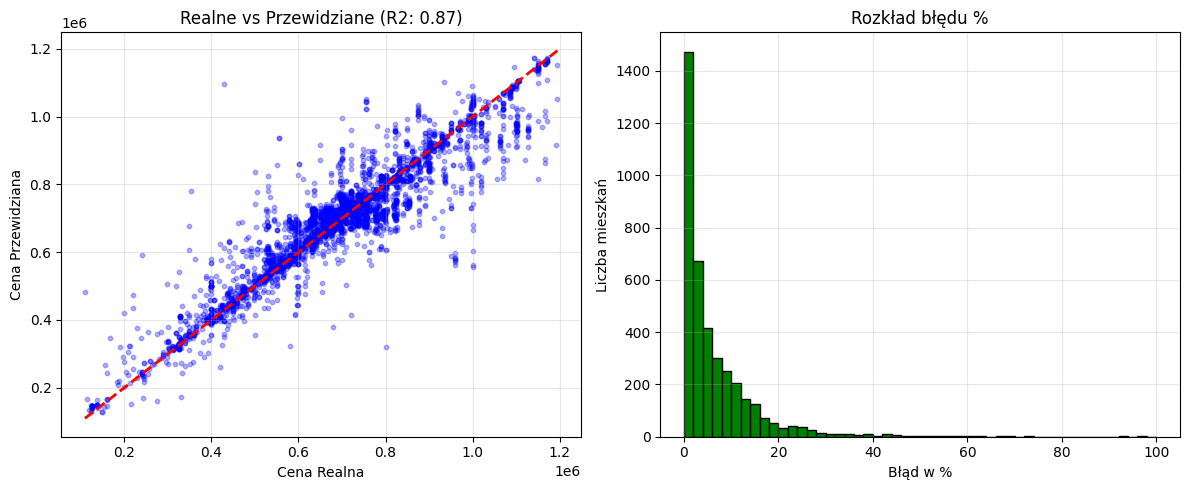

------------------------------
WYNIKI ANALIZY:
R2 Score:      0.8661
MAE:           43,180.12 PLN 
MAPE:          6.77% 
Mediana błędu: 22,470.67 PLN
------------------------------


In [22]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, median_absolute_error

# params
mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
medae = median_absolute_error(y_test, predictions)

# Błąd procentowy dla każdego mieszkania
errors_pct = (np.abs(y_test - predictions) / y_test) * 100

plt.figure(figsize=(12, 5))

# zestawienie ceny realne vs przewidywana idelanie to x = y
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.3, color='blue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Realne vs Przewidziane (R2: {r2:.2f})')
plt.xlabel('Cena Realna')
plt.ylabel('Cena Przewidziana')
plt.grid(True, alpha=0.3)

# Histogram błędów w procentach
plt.subplot(1, 2, 2)
plt.hist(errors_pct, bins=50, color='green', edgecolor='black', range=(0, 100))
plt.title('Rozkład błędu %')
plt.xlabel('Błąd w %')
plt.ylabel('Liczba mieszkań')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. RAPORT W KONSOLI
print("-" * 30)
print(f"WYNIKI ANALIZY:")
print(f"R2 Score:      {r2:.4f}")
print(f"MAE:           {mae:,.2f} PLN ")
print(f"MAPE:          {mape:.2%} ")
print(f"Mediana błędu: {medae:,.2f} PLN")
print("-" * 30)

# Notatki
- **Model Bazowy** - model bazowy przed wywaleniem outlierów ma średni błąd 174k z medianą błędu 77k, w kroku 2 wywalamy outliery
- **Model I** - po wywaleniu outlierów średni błąd modelu spadł do 58k i mediana 33k. Błąd to mniej niż 10%. Trochę mało próbek teraz mamy, może spróbuje dostarczć ich trochę więcej.
- **Model II** - w tym kroku wykonałem troche testów. Na zwiększeniu limitu ceny nieruchomości do 4mln udało się zyskać niespełna 50 recordów, a parametry błędu zmieniły się na niekożyść, więc całkowicie rezygnuje z tej strategii zwiększanai liczby próbek. Po odcięciu cen nieruchomości powyżej 2mln (dla kontekstu w poprzednim kroku było to 3mln), udało się nieco podciągnąć wyniki modelu, efekty tej operacji widać tabeli poniżej w wierszu 4. Finalnie udało mi się uzyskać następujące zestawienie zmiennych filtrujących, odcinających outliery, które gwarantuje najlepsze wyniki przedstawione w wierszu 5 tabeli:
    - Cena — zakres: `100k < tran_cena_brutto < 1 400k PLN`
    - Metraż — zakres: `15 < bud_pow_uzyt < 240 m²`
    - Cena za m² — zakres: `4 000 < price_per_m2 < 32 000 PLN/m²`

    W następnym kroku spróbuję jednak nieco rozszerzyć te zekresy, dodając jednocześnie filtracje tylko dla danych z roku 2025.
- **Model III** - Po filtracji od roku 2025, ubyło sporo próbek, średni błąd trochę wzrósł natomiast błąd procenotwy zmalał do 7.40%. Spróbuję jeszcze potestować inne modele ML.
- **Krok IV** - Po użyciu modelu XGBoost, praktycznie wszystkie wskaźniki efektywności udało się znacznie poprawić. Ale znalazłem jescze jedną super informacje. Okazuje się, że zmienna 'teryt' zawiera w sobie informacje o typie gminy! Zmienna teryt to 7-cyfrowy kokd, gdzie statnia cyfra mówi nam o typie gminy, co jest bezpośrednim wskaźnikiem „miejskości”:

    1 – gmina miejska (duże i średnie miasta).

    2 – gmina wiejska.
    
    3 – gmina miejsko-wiejska.
    
    8/9 – dzielnice (np. Warszawy).

    Dla modelu to ważne dane i myślę, że może to pomóc w uczeniu modelu. Dodam to do danych uczących i zobaczymy co z tego wyjdzie.
- **Krok V** - Po zdekodowaniu zmienej teryt, wyniki nie zmieniły się znacząco, wynik R2 nawet zmalał. XGBoost radzi sobie lepiej z kategoryzacją niż ja :), dlatego zamiast obrabiać mu dane dodam może jeszcze kilka, parametró uczących np. koordynaty położenia na mapie, prawo nieruchomościowe czy rodzaj budynku. 
- **Krok VI** - Po dodaniu kilku dodadkowyuch parametrów uczących zmaała mediana błędu oraz procentowy wskaźnik błędu. Błąd Średni wzrósł do 43k. Są to wyniki na ten moment zadowalające. Parametr R2 spadł do wartości 0.8661. 



---

| Model | Outliery | Dane uczące | Target | Średni błąd | Mediana błędu | R² | MAPE | Liczba próbek | Czas trenowania |
|---|---|---|---|---|---|---|---|---|---|
| Las losowy | z | Zestaw I | `tran_cena_brutto` | 174k | 77k | 0.8429 | śmieciowy (div/0) | 1124077 | 2min39s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 58k | 33k | 0.8526 | 9.78% | 47023 | 2,4s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 61k | 33k | 0.8401 | 10.17% | 47068 | 2,3s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 52k | 31k | 0.8726 | 9.27% | 46844 | 2,2s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 45k | 30k | 0.9121 | 8.53% | 46239 | 2,1s |
| Las losowy | bez | Zestaw I | `tran_cena_brutto` | 56k | 30k | 0.8492 | 7.40% | 4703  | 0,3s |
| XGBoost    | bez | Zestaw I | `tran_cena_brutto` | 36k | 23k | 0.9372 | 7.14% | 46239 | 2,4s |
| XGBoost    | bez | Zestaw II | `tran_cena_brutto` | 36k | 23k | 0.9239 | 7.23% | 45517 | 1,0s |
| XGBoost    | bez | Zestaw III | `tran_cena_brutto` | 43K | 22K | 0.8661 | 6.77% | 19888 | 1,2s |

---

- Zestaw I: `features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac']`
- Zestaw II: `features = features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'rok', 'miesiac', 'gmina', 
    'czy_warszawa']`
- Zestaw III: `features = ['bud_pow_uzyt', 'RynekPierwotny', 'Sprzedajacy', 'teryt', 'rok', 'miesiac',
    'lon', 'lat', 'bud_rodzaj', 'nier_prawo']`
